# Solution of Problem Set 3

In [152]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

## Exercise 2.1: Regularisation



In [153]:
# Ridge regression with numerical optimisation (overfitted polynomial setting)
df = pd.read_csv("../assets/data/data_driven_modelling/methylene_blue.csv")
x = df["Concentration (µM)"].to_numpy(dtype=float)
y = df["Absorbance"].to_numpy(dtype=float)

# standardise the data
x = (x - x.mean()) / x.std()

# Split the data into training and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=None)

deg = 15
lam = 0.01

def ridge_loss(beta, x, y, lam):
    predictions = np.polyval(beta, x)
    residuals = predictions - y
    l2_penalty = np.sum(beta[:-1] ** 2)
    return np.mean(residuals**2) + lam * l2_penalty

beta_non_rigde = np.polyfit(x_train, y_train, deg)
result = minimize(
    ridge_loss,
    beta_non_rigde,
    args=(x_train, y_train, lam),
    method="BFGS",
    options={"maxiter": 1000}
)

if not result.success:
    print(f"Warning: optimizer did not converge ({result.message}).")

beta_ridge = result.x
train_loss = np.mean((y_train - np.polyval(beta_ridge, x_train)) ** 2)
test_loss = np.mean((y_test - np.polyval(beta_ridge, x_test)) ** 2)

print(f"Train loss (MSE): {train_loss:.6g}")
print(f"Test loss (MSE): {test_loss:.6g}")

Train loss (MSE): 0.00023532
Test loss (MSE): 0.000268409


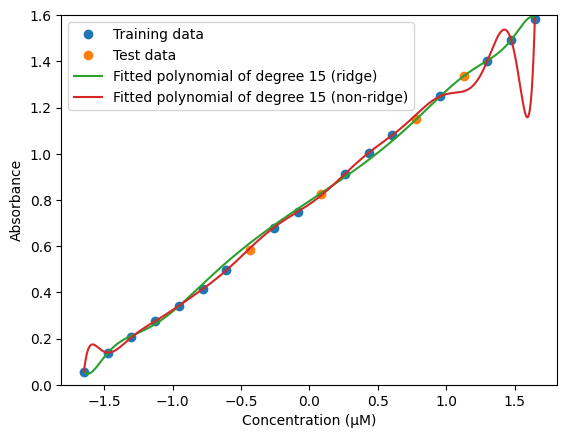

In [154]:
x_range = np.linspace(x.min(), x.max(), 1000)
plt.plot(x_train, y_train, 'o', label='Training data')
plt.plot(x_test, y_test, 'o', label='Test data')
plt.plot(x_range, np.polyval(beta_ridge, x_range), label=f'Fitted polynomial of degree {deg} (ridge)')
plt.plot(x_range, np.polyval(beta_non_rigde, x_range), label=f'Fitted polynomial of degree {deg} (non-ridge)')
plt.xlabel('Concentration (µM)')
plt.ylabel('Absorbance')
plt.ylim(0.0, 1.6)
plt.legend()
plt.show()

## Exercise 2.2: Kernel SVM 

In [155]:
# Reuse the simple linear SVM from the classification chapter.
# The bias is the feature x_0 = 1, so beta has length dim + 1 and labels are -1/+1.
class SupportVectorMachine:
    def __init__(self, dim=2, alpha=0.1, n_epochs=100, lam=0.1):
        self.alpha = alpha
        self.n_epochs = n_epochs
        self.lam = lam
        self.beta = np.random.randn(dim + 1)

    def net_input(self, x):
        return x @ self.beta

    def fit(self, X, y):
        N = len(X)
        for _ in range(self.n_epochs):
            for xi, yi in zip(X, y):
                update = yi if yi * self.net_input(xi) < 1.0 else 0.0
                self.beta += self.alpha * (update * xi / N - self.lam * self.beta)
        return self

    def predict(self, x):
        return np.where(self.net_input(x) >= 0.0, 1, -1)

Training accuracy: 1.00


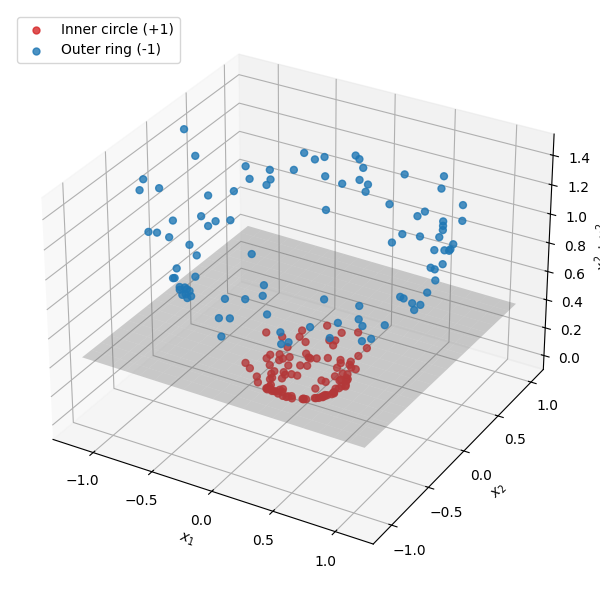

In [156]:
np.random.seed(0)

# Two concentric circles in 2D: not linearly separable in the original space.
X2d, y01 = make_circles(n_samples=200, factor=0.3, noise=0.08, random_state=0)
y = np.where(y01 == 1, 1, -1)  # inner circle -> +1, outer ring -> -1

# Radial feature map lifting the data to 3D: (x1, x2) -> (x1, x2, x1^2 + x2^2).
# The squared radius separates the inner from the outer circle along the new axis.
z3 = X2d[:, 0] ** 2 + X2d[:, 1] ** 2
Z = np.column_stack([X2d[:, 0], X2d[:, 1], z3])

# Augment with the bias feature x_0 = 1 and train the linear SVM in 3D.
Z_aug = np.hstack([np.ones((len(Z), 1)), Z])
svm = SupportVectorMachine(dim=3, alpha=0.5, n_epochs=100, lam=0.001)
svm.fit(Z_aug, y)
print(f"Training accuracy: {np.mean(svm.predict(Z_aug) == y):.2f}")

# The learned hyperplane b0 + b1*z1 + b2*z2 + b3*z3 = 0 is a separating plane in 3D.
b0, b1, b2, b3 = svm.beta
g1, g2 = np.meshgrid(
    np.linspace(X2d[:, 0].min(), X2d[:, 0].max(), 20),
    np.linspace(X2d[:, 1].min(), X2d[:, 1].max(), 20),
)
plane_z = -(b0 + b1 * g1 + b2 * g2) / b3

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection="3d")
ax.scatter(Z[y == 1, 0], Z[y == 1, 1], Z[y == 1, 2],
           color="tab:red", s=25, alpha=0.8, label="Inner circle (+1)")
ax.scatter(Z[y == -1, 0], Z[y == -1, 1], Z[y == -1, 2],
           color="tab:blue", s=25, alpha=0.8, label="Outer ring (-1)")
ax.plot_surface(g1, g2, plane_z, color="gray", alpha=0.3, edgecolor="none")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$x_1^2 + x_2^2$")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()